In [1]:
import sys

sys.path.append("../")

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns
import torch
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score
from torch import nn
from torch_geometric.nn.models import GCN
from tqdm.auto import tqdm

from gjepa.datasets import SupervisedGNNNodeLevelDataModule

In [3]:
import warnings

warnings.filterwarnings(action="ignore", message=".*is_categorical_dtype is deprecated.*")
warnings.filterwarnings(action="ignore", message=".*use_inf_as_na option is deprecated.*")

In [4]:
class Model(nn.Module):
    def __init__(self, in_dim: int, use_proj: bool):
        super().__init__()
        if use_proj:
            self.proj = nn.Linear(in_dim, 16)
            in_dim = 16
        else:
            self.proj = nn.Identity()

        self.gnn = GCN(in_channels=in_dim, hidden_channels=16, num_layers=2)
        self.lin = nn.Linear(16, 7)
        self.loss_fn = nn.CrossEntropyLoss()

    def forward(self, x, edge_index, ptr):
        h = self.proj(x)
        z = self.gnn(h, edge_index)[ptr]
        pred = self.lin(z)
        return z, pred

In [5]:
def extract_z_ygt_ypred(model, feature_fn, loader):
    z_all, y_gt_all, y_pred_all = [], [], []
    for batch in loader:
        z, yp = model(
            x=feature_fn(batch),
            edge_index=batch.edge_index,
            ptr=batch.ptr[:-1],
        )
        y = batch.y[batch.ptr[:-1]]
        z_all.append(z)
        y_gt_all.append(y)
        y_pred_all.append(yp)

    z_all = torch.cat(z_all, dim=0).numpy()
    y_gt_all = torch.cat(y_gt_all, dim=0).numpy()
    y_pred_all = torch.cat(y_pred_all, dim=0).argmax(dim=-1).numpy()

    return z_all, y_gt_all, y_pred_all


def run_model(in_dim: int, num_epochs: int, feature_fn, use_proj: bool):
    dm = SupervisedGNNNodeLevelDataModule(
        path="../data/subgraphs_dataset/Cora_laplacian_2.pt",
        batch_size=32,
    )

    model = Model(in_dim=in_dim, use_proj=use_proj)
    opt = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=5e-4)

    train_loss = []
    epochs = []
    val_f1_lr, test_f1_lr = [], []
    val_f1_head, test_f1_head = [], []

    for epoch in tqdm(range(num_epochs)):
        model.train()
        for batch in dm.train_dataloader():
            opt.zero_grad()

            _, pred = model(x=feature_fn(batch), edge_index=batch.edge_index, ptr=batch.ptr[:-1])
            gt = batch.y[batch.ptr[:-1]]

            loss = model.loss_fn(input=pred, target=gt)

            loss.backward()
            opt.step()

            train_loss.append(loss.item())

        if epoch % 10 == 0:
            epochs.append(epoch)
            model.eval()
            with torch.no_grad():
                z_train, y_train, _ = extract_z_ygt_ypred(
                    model=model,
                    feature_fn=feature_fn,
                    loader=dm.train_dataloader(),
                )

                z_val, y_val, y_pred_val = extract_z_ygt_ypred(
                    model=model,
                    feature_fn=feature_fn,
                    loader=dm.val_dataloader(),
                )

                z_test, y_test, y_pred_test = extract_z_ygt_ypred(
                    model=model,
                    feature_fn=feature_fn,
                    loader=dm.test_dataloader(),
                )

            lr = LogisticRegression(max_iter=500)
            lr.fit(z_train, y_train)
            val_f1_lr.append(f1_score(y_true=y_val, y_pred=lr.predict(z_val), average="macro"))
            test_f1_lr.append(f1_score(y_true=y_test, y_pred=lr.predict(z_test), average="macro"))

            val_f1_head.append(f1_score(y_true=y_val, y_pred=y_pred_val, average="macro"))
            test_f1_head.append(f1_score(y_true=y_test, y_pred=y_pred_test, average="macro"))

    fig, axs = plt.subplots(ncols=3, figsize=(15, 5))
    sns.lineplot(x=range(len(train_loss)), y=train_loss, ax=axs[0])
    axs[0].set(title="Train loss")

    sns.lineplot(x=epochs, y=val_f1_lr, ax=axs[1], label="Val")
    sns.lineplot(x=epochs, y=test_f1_lr, ax=axs[1], label="Test")

    best_val_f1 = max(val_f1_lr)
    idx = val_f1_lr.index(best_val_f1)
    best_epoch = epochs[idx]
    best_test_f1 = test_f1_lr[idx]

    axs[1].set(
        title=f"Logistic Regression: F1-macro\nBest epoch={best_epoch:03d} val_f1={best_val_f1:.4f} test_f1={best_test_f1:.4f}"
    )

    sns.lineplot(x=epochs, y=val_f1_head, ax=axs[2], label="Val")
    sns.lineplot(x=epochs, y=test_f1_head, ax=axs[2], label="Test")

    best_val_f1 = max(val_f1_head)
    idx = val_f1_head.index(best_val_f1)
    best_epoch = epochs[idx]
    best_test_f1 = test_f1_head[idx]

    axs[2].set(
        title=f"Head F1-macro\nBest epoch={best_epoch:03d} val_f1={best_val_f1:.4f} test_f1={best_test_f1:.4f}"
    )

### Run on original features

  0%|          | 0/100 [00:00<?, ?it/s]

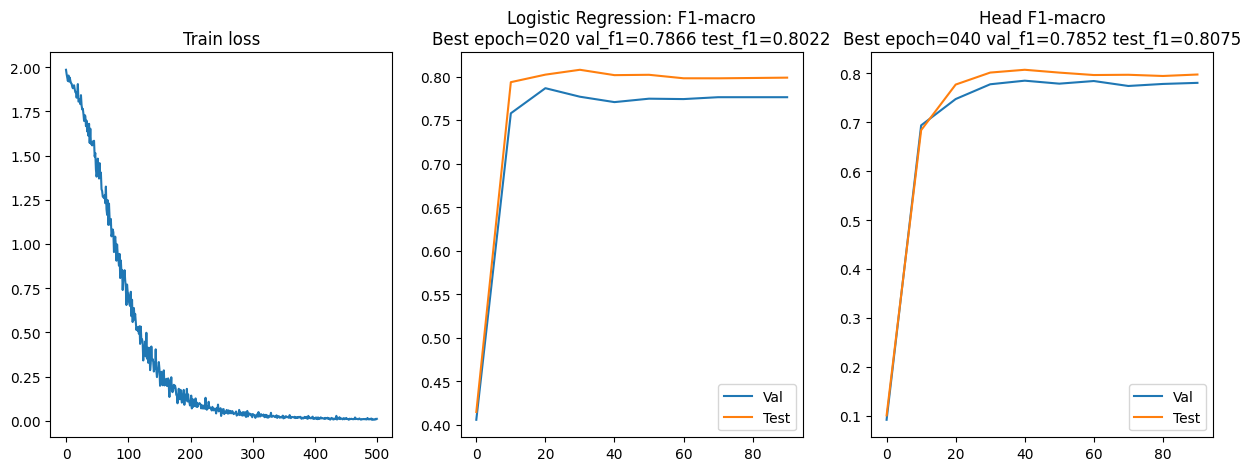

In [6]:
run_model(in_dim=1433, num_epochs=100, feature_fn=lambda b: b.x, use_proj=False)

  0%|          | 0/100 [00:00<?, ?it/s]

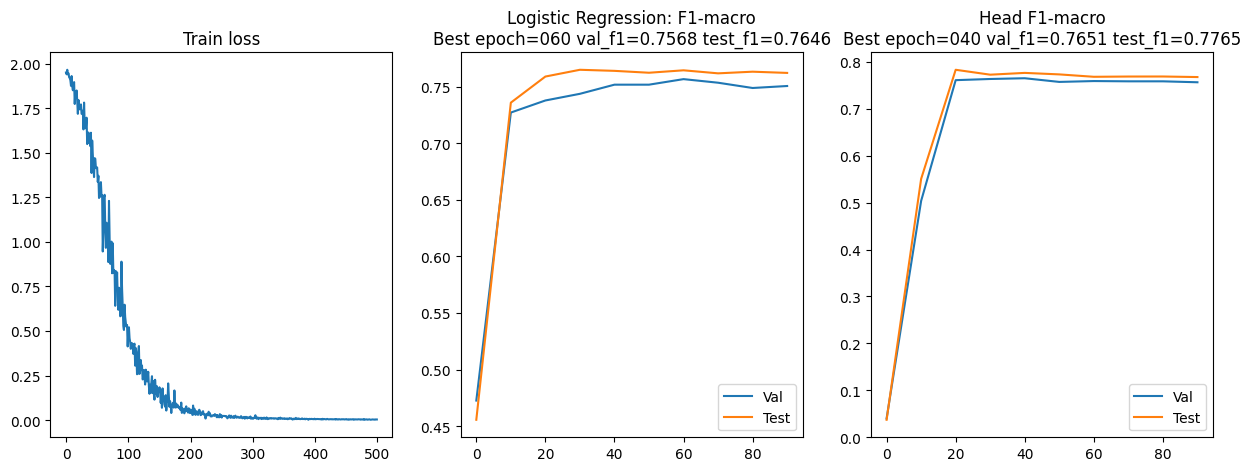

In [7]:
run_model(in_dim=1433, num_epochs=100, feature_fn=lambda b: b.x, use_proj=True)

### Run on positional only

  0%|          | 0/100 [00:00<?, ?it/s]

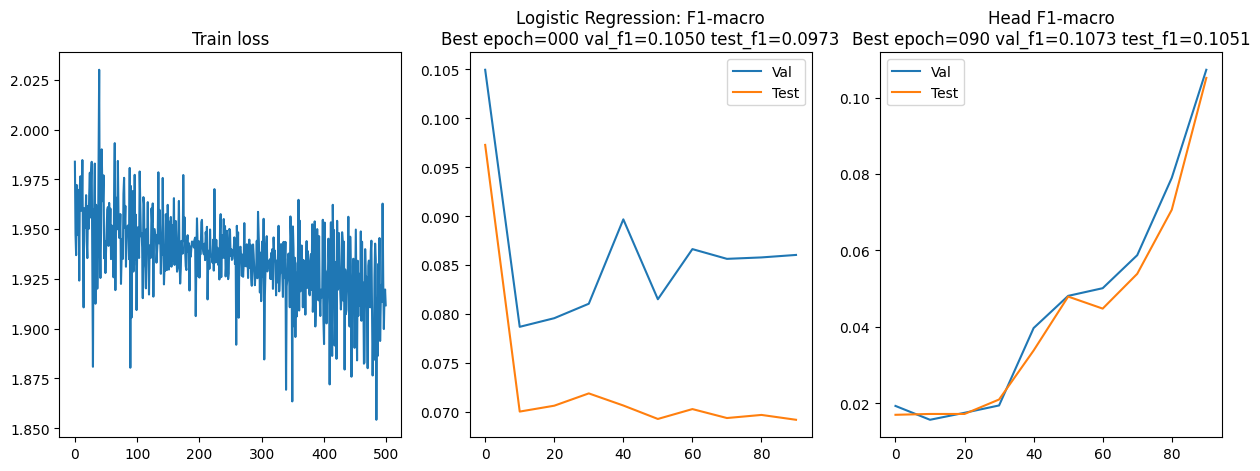

In [8]:
run_model(in_dim=8, num_epochs=100, feature_fn=lambda b: b.pos, use_proj=False)

### Run on combined

  0%|          | 0/100 [00:00<?, ?it/s]

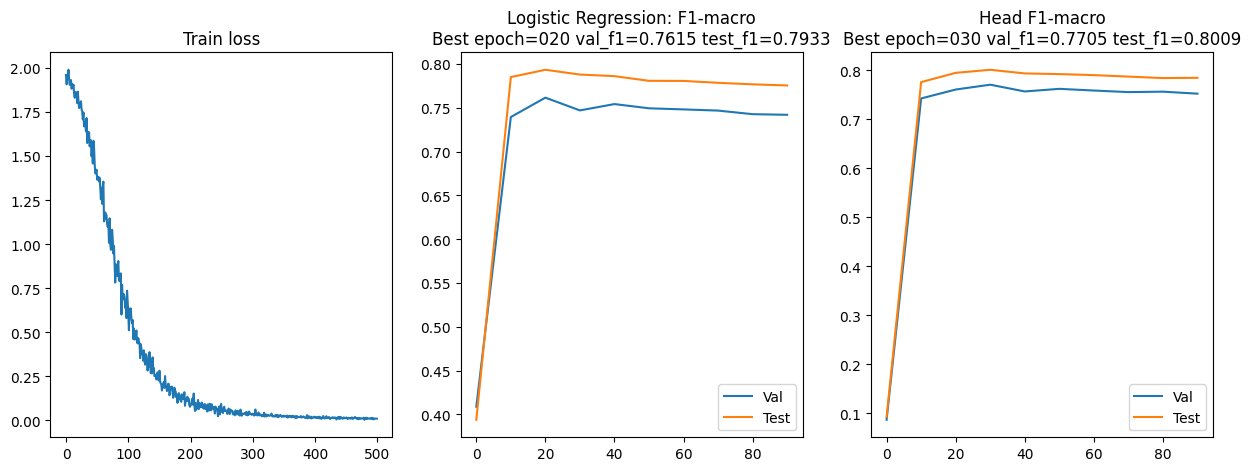

In [9]:
run_model(
    in_dim=1433 + 8,
    num_epochs=100,
    feature_fn=lambda b: torch.cat([b.x, b.pos], dim=-1),
    use_proj=False,
)

### Analyse positional encodings

In [10]:
from gjepa.datasets.node_level import load_graph

cora = load_graph(name="Cora", pre_transform=None)

Processing...
Done!


In [11]:
from lightning_fabric import seed_everything
from gjepa.transforms import DeterministicAddLaplacianEigenvectorPE as AddLaplacianEigenvectorPE

node_mask = torch.zeros(cora.num_nodes).bool()
node_mask[cora.train_mask] = True
node_mask[cora.val_mask] = True
node_mask[cora.test_mask] = True

laplacian_pes = {}

for k in tqdm((2, 4, 8, 16)):
    seed_everything(2137)

    pes = AddLaplacianEigenvectorPE(k=k, attr_name="pos")(cora.clone()).pos
    pes = pes[node_mask]
    laplacian_pes[k] = pes

  0%|          | 0/4 [00:00<?, ?it/s]

Global seed set to 2137
Global seed set to 2137
Global seed set to 2137
Global seed set to 2137


In [12]:
dm = SupervisedGNNNodeLevelDataModule(
    path="../data/subgraphs_dataset/Cora_laplacian_2.pt",
    batch_size=32,
)

pos = torch.stack(
    [graph.pos[0] for split in ("train", "val", "test") for graph in dm.dataset[split]],
    dim=0,
)

pos.shape

torch.Size([1640, 8])

In [13]:
from sklearn.decomposition import PCA


def analyse_pos(pos_enc: torch.Tensor, name: str):
    unique_pos_enc, counts = pos_enc.unique(dim=0, return_counts=True)

    print(f"---- {name} ----")
    print("#Unique:", unique_pos_enc.shape)
    print("Top counts:", counts.sort(descending=True).values[:5])

    # pos2d = PCA(n_components=2).fit_transform(unique_pos_enc)

    # fig, axs = plt.subplots(ncols=2, figsize=(15, 5))
    # sns.scatterplot(x=pos2d[:, 0], y=pos2d[:, 1], ax=axs[0])

    # for x, y, c in zip(pos2d[:, 0], pos2d[:, 1], counts.tolist()):
    #     axs[0].text(x + .02, y, str(c))

    # axs[0].set(title=f"PCA for {name}")

    # pairwise_dist = torch.cdist(unique_pos_enc, unique_pos_enc, p=2)
    # idx = torch.triu_indices(*pairwise_dist.shape)
    # pairwise_dist[~idx[0], ~idx[1]] = 0
    # pairwise_dist /= pairwise_dist.max()

    # sns.heatmap(pairwise_dist, cmap="gray_r", ax=axs[1])
    # axs[1].set(title="Pairwise dists")

    # fig.suptitle(name)

In [14]:
analyse_pos(pos_enc=pos, name="Current dataset (k=8)")

---- Current dataset (k=8) ----
#Unique: torch.Size([1617, 8])
Top counts: tensor([12,  2,  2,  2,  2])


In [15]:
for k, pos_enc in laplacian_pes.items():
    analyse_pos(pos_enc=pos_enc, name=f"Cora - Laplacian k={k}")

---- Cora - Laplacian k=2 ----
#Unique: torch.Size([1615, 2])
Top counts: tensor([14,  2,  2,  2,  2])
---- Cora - Laplacian k=4 ----
#Unique: torch.Size([1617, 4])
Top counts: tensor([12,  2,  2,  2,  2])
---- Cora - Laplacian k=8 ----
#Unique: torch.Size([1617, 8])
Top counts: tensor([12,  2,  2,  2,  2])
---- Cora - Laplacian k=16 ----
#Unique: torch.Size([1617, 16])
Top counts: tensor([12,  2,  2,  2,  2])


In [16]:
(laplacian_pes[8] == pos).all(dim=1).all()

tensor(True)